In [2]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

In [3]:
inputs = np.array([1, -1])
weights = np.array([0.23, 0.77])

### Perceptron

In [4]:
class Perceptron:
    def sign(self, x):    ## Activator function
        if x >= 0:
            return 1
        else:
            return -1

    def guess(self, inputs):    ## Neuron
        # Initialize the weights randomly
        weights = np.random.uniform(-1, 1, len(inputs))
        ssum = 0
        for innput, weight in zip(inputs, weights):
            ssum += innput*weight

        self.output = self.sign(ssum)
        return self.output

In [5]:
inputs = np.array([1, 0.5])
p = Perceptron()
p.guess(inputs)

-1

### Training points

In [6]:
class Point:
    def __init__(self, width, height):
        self.x = np.random.uniform(-1, 1, width)
        self.y = np.random.uniform(-1, 1, height)
        self.labels = []
    
    def point(self):
        for x, y in zip(self.x, self.y):
            if x > y:
                self.labels.append(1)
            else:
                self.labels.append(-1)

        return self.labels
    def show(self):
        pass

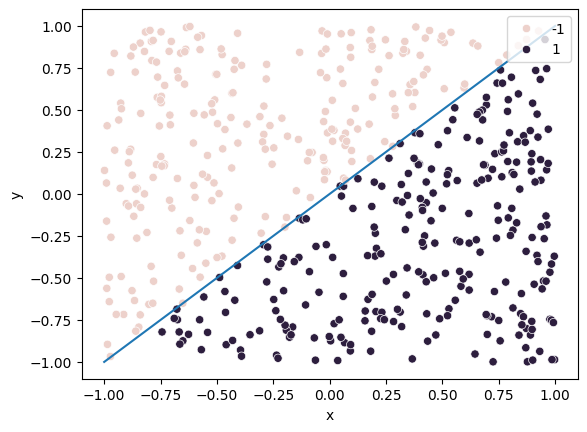

In [7]:
points = Point(500, 500)

labels = points.point()
x = points.x
y = points.y
df = pd.DataFrame({'x':x, 'y':y})

sns.scatterplot(df, x='x', y='y', hue=labels)
plt.plot([-1, 1], [-1, 1])

In [27]:
df

,x,y,bias
0,-0.647593,0.766756,1
1,-0.541271,-0.923803,1
2,0.842345,0.560090,1
3,0.358450,0.701428,1
4,-0.929506,-0.482310,1
...,...,...,...
495,0.422753,0.903312,1
496,-0.846034,-0.019381,1
497,-0.919228,0.944999,1
498,-0.891156,-0.181608,1


In [28]:
labels

[1,
 -1,
 1,
 1,
 -1,
 1,
 -1,
 1,
 1,
 1,
 -1,
 1,
 1,
 -1,
 -1,
 1,
 -1,
 1,
 1,
 1,
 1,
 -1,
 1,
 1,
 1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 1,
 -1,
 -1,
 1,
 -1,
 1,
 -1,
 1,
 1,
 -1,
 -1,
 1,
 1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 1,
 1,
 -1,
 1,
 1,
 1,
 -1,
 1,
 -1,
 1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 1,
 -1,
 -1,
 -1,
 1,
 1,
 -1,
 1,
 -1,
 1,
 1,
 1,
 -1,
 1,
 -1,
 -1,
 1,
 -1,
 -1,
 1,
 -1,
 1,
 1,
 1,
 -1,
 1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 1,
 -1,
 1,
 1,
 -1,
 1,
 1,
 -1,
 1,
 -1,
 -1,
 1,
 1,
 -1,
 -1,
 1,
 1,
 -1,
 1,
 -1,
 1,
 -1,
 -1,
 -1,
 1,
 -1,
 1,
 1,
 -1,
 1,
 -1,
 1,
 1,
 -1,
 -1,
 1,
 -1,
 1,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 1,
 1,
 -1,
 -1,
 -1,
 1,
 1,
 -1,
 1,
 1,
 1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 1,
 -1,
 -1,
 1,
 1,
 1,
 -1,
 -1,
 1,
 -1,
 1,
 -1,
 -1,
 1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 1,
 1,
 -1,
 1,
 -1,
 

### Adding training function

In [9]:
class Perceptron:
    def __init__(self):
        self.lr = 0.1
        self.weights = np.random.uniform(-1, 1, 2)
        
    def sign(self, x):    ## Activator function
        if x >= 0:
            return 1
        else:
            return -1

    def guess(self, inputs):    ## Neuron
        ssum = 0
        for innput, weight in zip(inputs, self.weights):
            ssum += innput*weight

        self.output = self.sign(ssum)
        return self.output


    def train(self, inputs, target):
        guess = self.guess(inputs)
        error = target - guess

        # Tune all the weights
        for idx in range(len(self.weights)):
            self.weights[idx] += error * inputs.iloc[idx]*self.lr
            

In [10]:
inputs = np.array([1, 0.5])
p = Perceptron()
p.guess(inputs)

-1

In [11]:
for idx in range(len(labels)):
    p.train(df.iloc[idx], labels[idx])

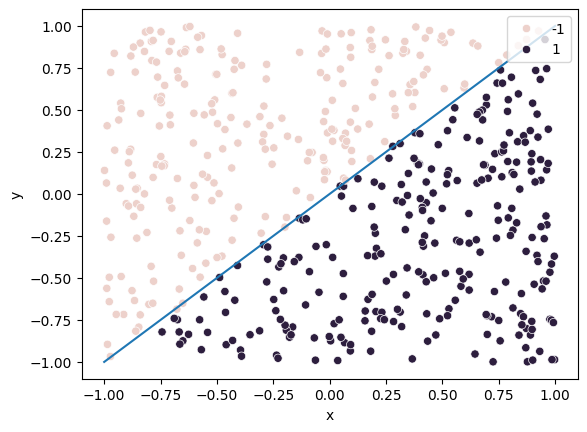

In [12]:
guesses = []
for idx in range(len(df)):
    pred = p.guess(df.iloc[idx])
    guesses.append(pred)
sns.scatterplot(df, x='x', y='y', hue=guesses)
plt.plot([-1, 1], [-1, 1])

In [13]:
accuracy_score(guesses, labels)

0.996

## Level 2

In [14]:
def f(x):
    # y = mx + b
    return 0.3*x + 0.2

class Point:
    def __init__(self, width, height):
        self.x = np.random.uniform(-1, 1, width)
        self.y = np.random.uniform(-1, 1, height)
        self.labels = []
    
    def point(self):
        for x, y in zip(self.x, self.y):
            lineY = f(x)
            if y > lineY:
                self.labels.append(1)
            else:
                self.labels.append(-1)

        return self.labels

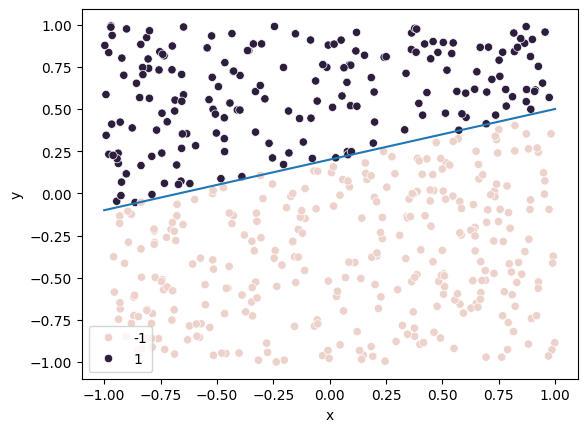

In [15]:
points = Point(500, 500)

labels = points.point()
x = points.x
y = points.y

df = pd.DataFrame({'x':x, 'y':y})
sns.scatterplot(df, x='x', y='y', hue=labels)
plt.plot([-1, 1], [f(-1), f(1)])

### Training

In [16]:
p = Perceptron()

In [17]:
for idx in range(len(labels)):
    p.train(df.iloc[idx], labels[idx])

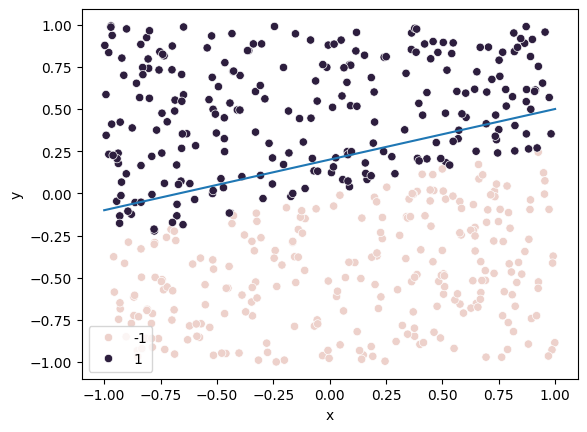

In [18]:
guesses = []
for idx in range(len(df)):
    pred = p.guess(df.iloc[idx])
    guesses.append(pred)
sns.scatterplot(df, x='x', y='y', hue=guesses)
plt.plot([-1, 1], [f(-1), f(1)])

In [19]:
accuracy_score(guesses, labels)

0.886

### Adding Bias

In [20]:
class Point:
    def __init__(self, width, height):
        self.x = np.random.uniform(-1, 1, width)
        self.y = np.random.uniform(-1, 1, height)
        self.bias = 1
        self.labels = []
    
    def point(self):
        for x, y in zip(self.x, self.y):
            lineY = f(x)
            if y > lineY:
                self.labels.append(1)
            else:
                self.labels.append(-1)

        return self.labels

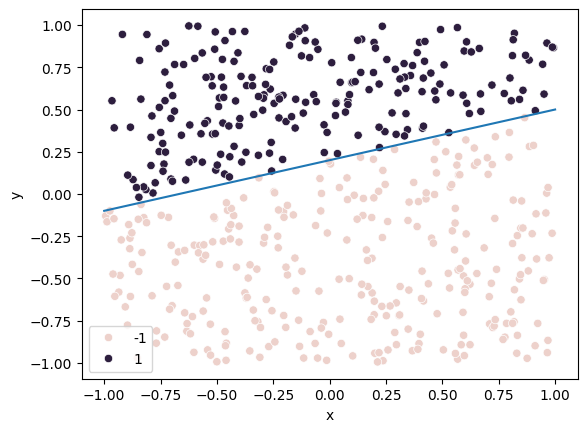

In [21]:
points = Point(500, 500)

labels = points.point()
x = points.x
y = points.y

df = pd.DataFrame({'x':x, 'y':y, 'bias':points.bias})

sns.scatterplot(df, x='x', y='y', hue=labels)
plt.plot([-1, 1], [f(-1), f(1)])

In [22]:
class Perceptron:
    def __init__(self, n):
        self.lr = 0.1
        self.weights = np.random.uniform(-1, 1, n)
        
    def sign(self, x):    ## Activator function
        if x >= 0:
            return 1
        else:
            return -1

    def guess(self, inputs):    ## Neuron
        ssum = 0
        for innput, weight in zip(inputs, self.weights):
            ssum += innput*weight

        self.output = self.sign(ssum)
        return self.output


    def train(self, inputs, target):
        guess = self.guess(inputs)
        error = target - guess

        # Tune all the weights
        for idx in range(len(self.weights)):
            self.weights[idx] += error * inputs.iloc[idx]*self.lr
            

In [23]:
p = Perceptron(3)

In [24]:
for idx in range(len(labels)):
    p.train(df.iloc[idx], labels[idx])

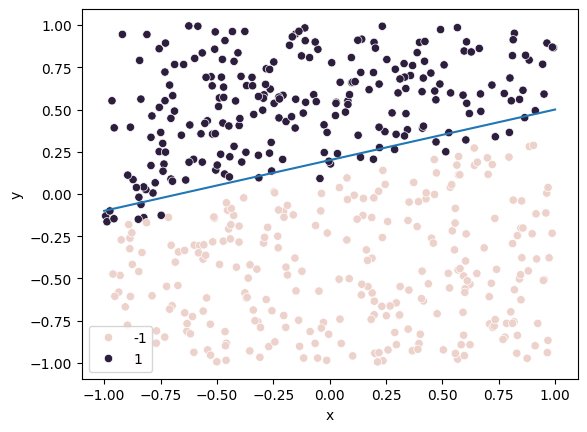

In [25]:
guesses = []
for idx in range(len(df)):
    pred = p.guess(df.iloc[idx])
    guesses.append(pred)
sns.scatterplot(df, x='x', y='y', hue=guesses)
plt.plot([-1, 1], [f(-1), f(1)])

In [26]:
accuracy_score(guesses, labels)

0.958

I have no idea why it is working.